# **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

# **Set up the visualization style**

In [ ]:
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **Load and clean the dataset**

In [ ]:
df = pd.read_csv('dataset.csv', sep=';')
df = df.set_index('Id')                                                           ############# Set 'Id' column as index
df = df.apply(lambda x: x.str.replace(',', '.').astype(float))                    ############# Replace ',' with '.' and convert to float

# **Exploratory data analysis**

In [ ]:
print(df.head())
print(df.describe())

    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
Id                                                                            
0             7.4              0.70         0.00             1.9      0.076   
1             7.8              0.88         0.00             2.6      0.098   
2             7.8              0.76         0.04             2.3      0.092   
3            11.2              0.28         0.56             1.9      0.075   
4             7.4              0.70         0.00             1.9      0.076   

    free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
Id                                                                        
0                  11.0                  34.0   0.9978  3.51       0.56   
1                  25.0                  67.0   0.9968  3.20       0.68   
2                  15.0                  54.0   0.9970  3.26       0.65   
3                  17.0                  60.0   0.9980  3.16       0.58

# **Check for missing values**

In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64


# **Visualizations**

In [ ]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

# **Heatmap of correlations**

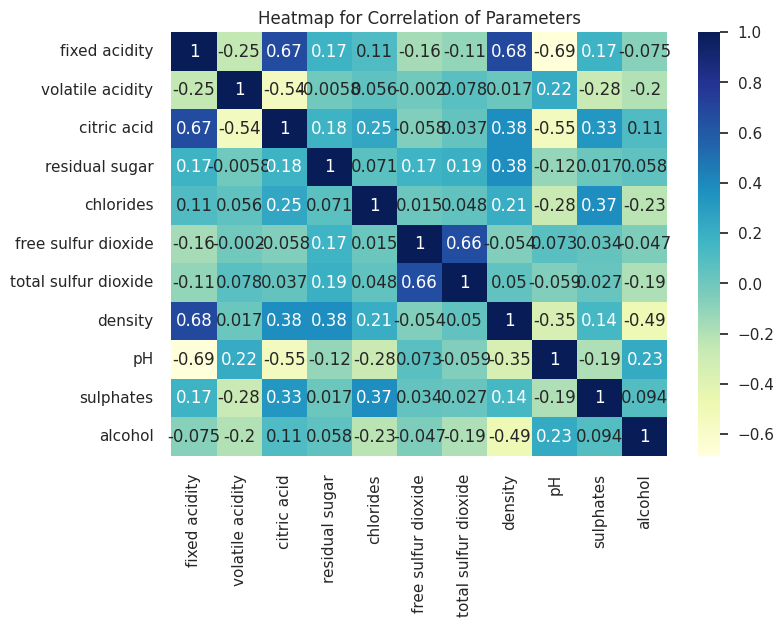

In [ ]:
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)
plt.title('Heatmap for Correlation of Parameters')
plt.show()


# **Histograms of features**

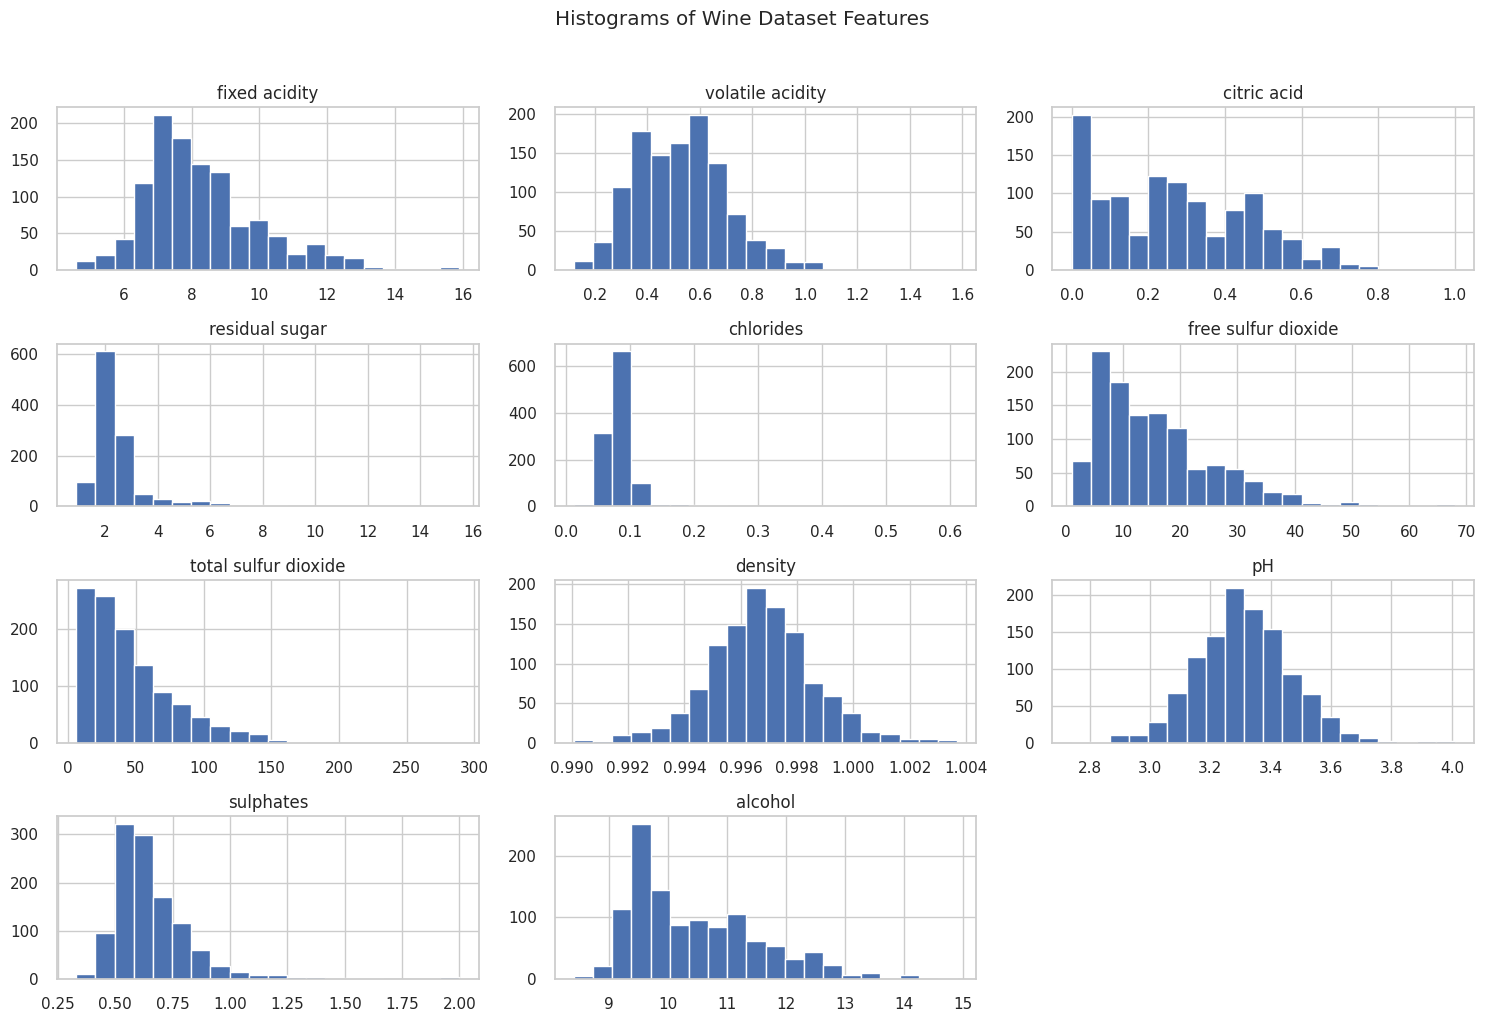

In [ ]:
df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Histograms of Wine Dataset Features", y=1.02)
plt.tight_layout()
plt.show()

# **Pairplot of features**

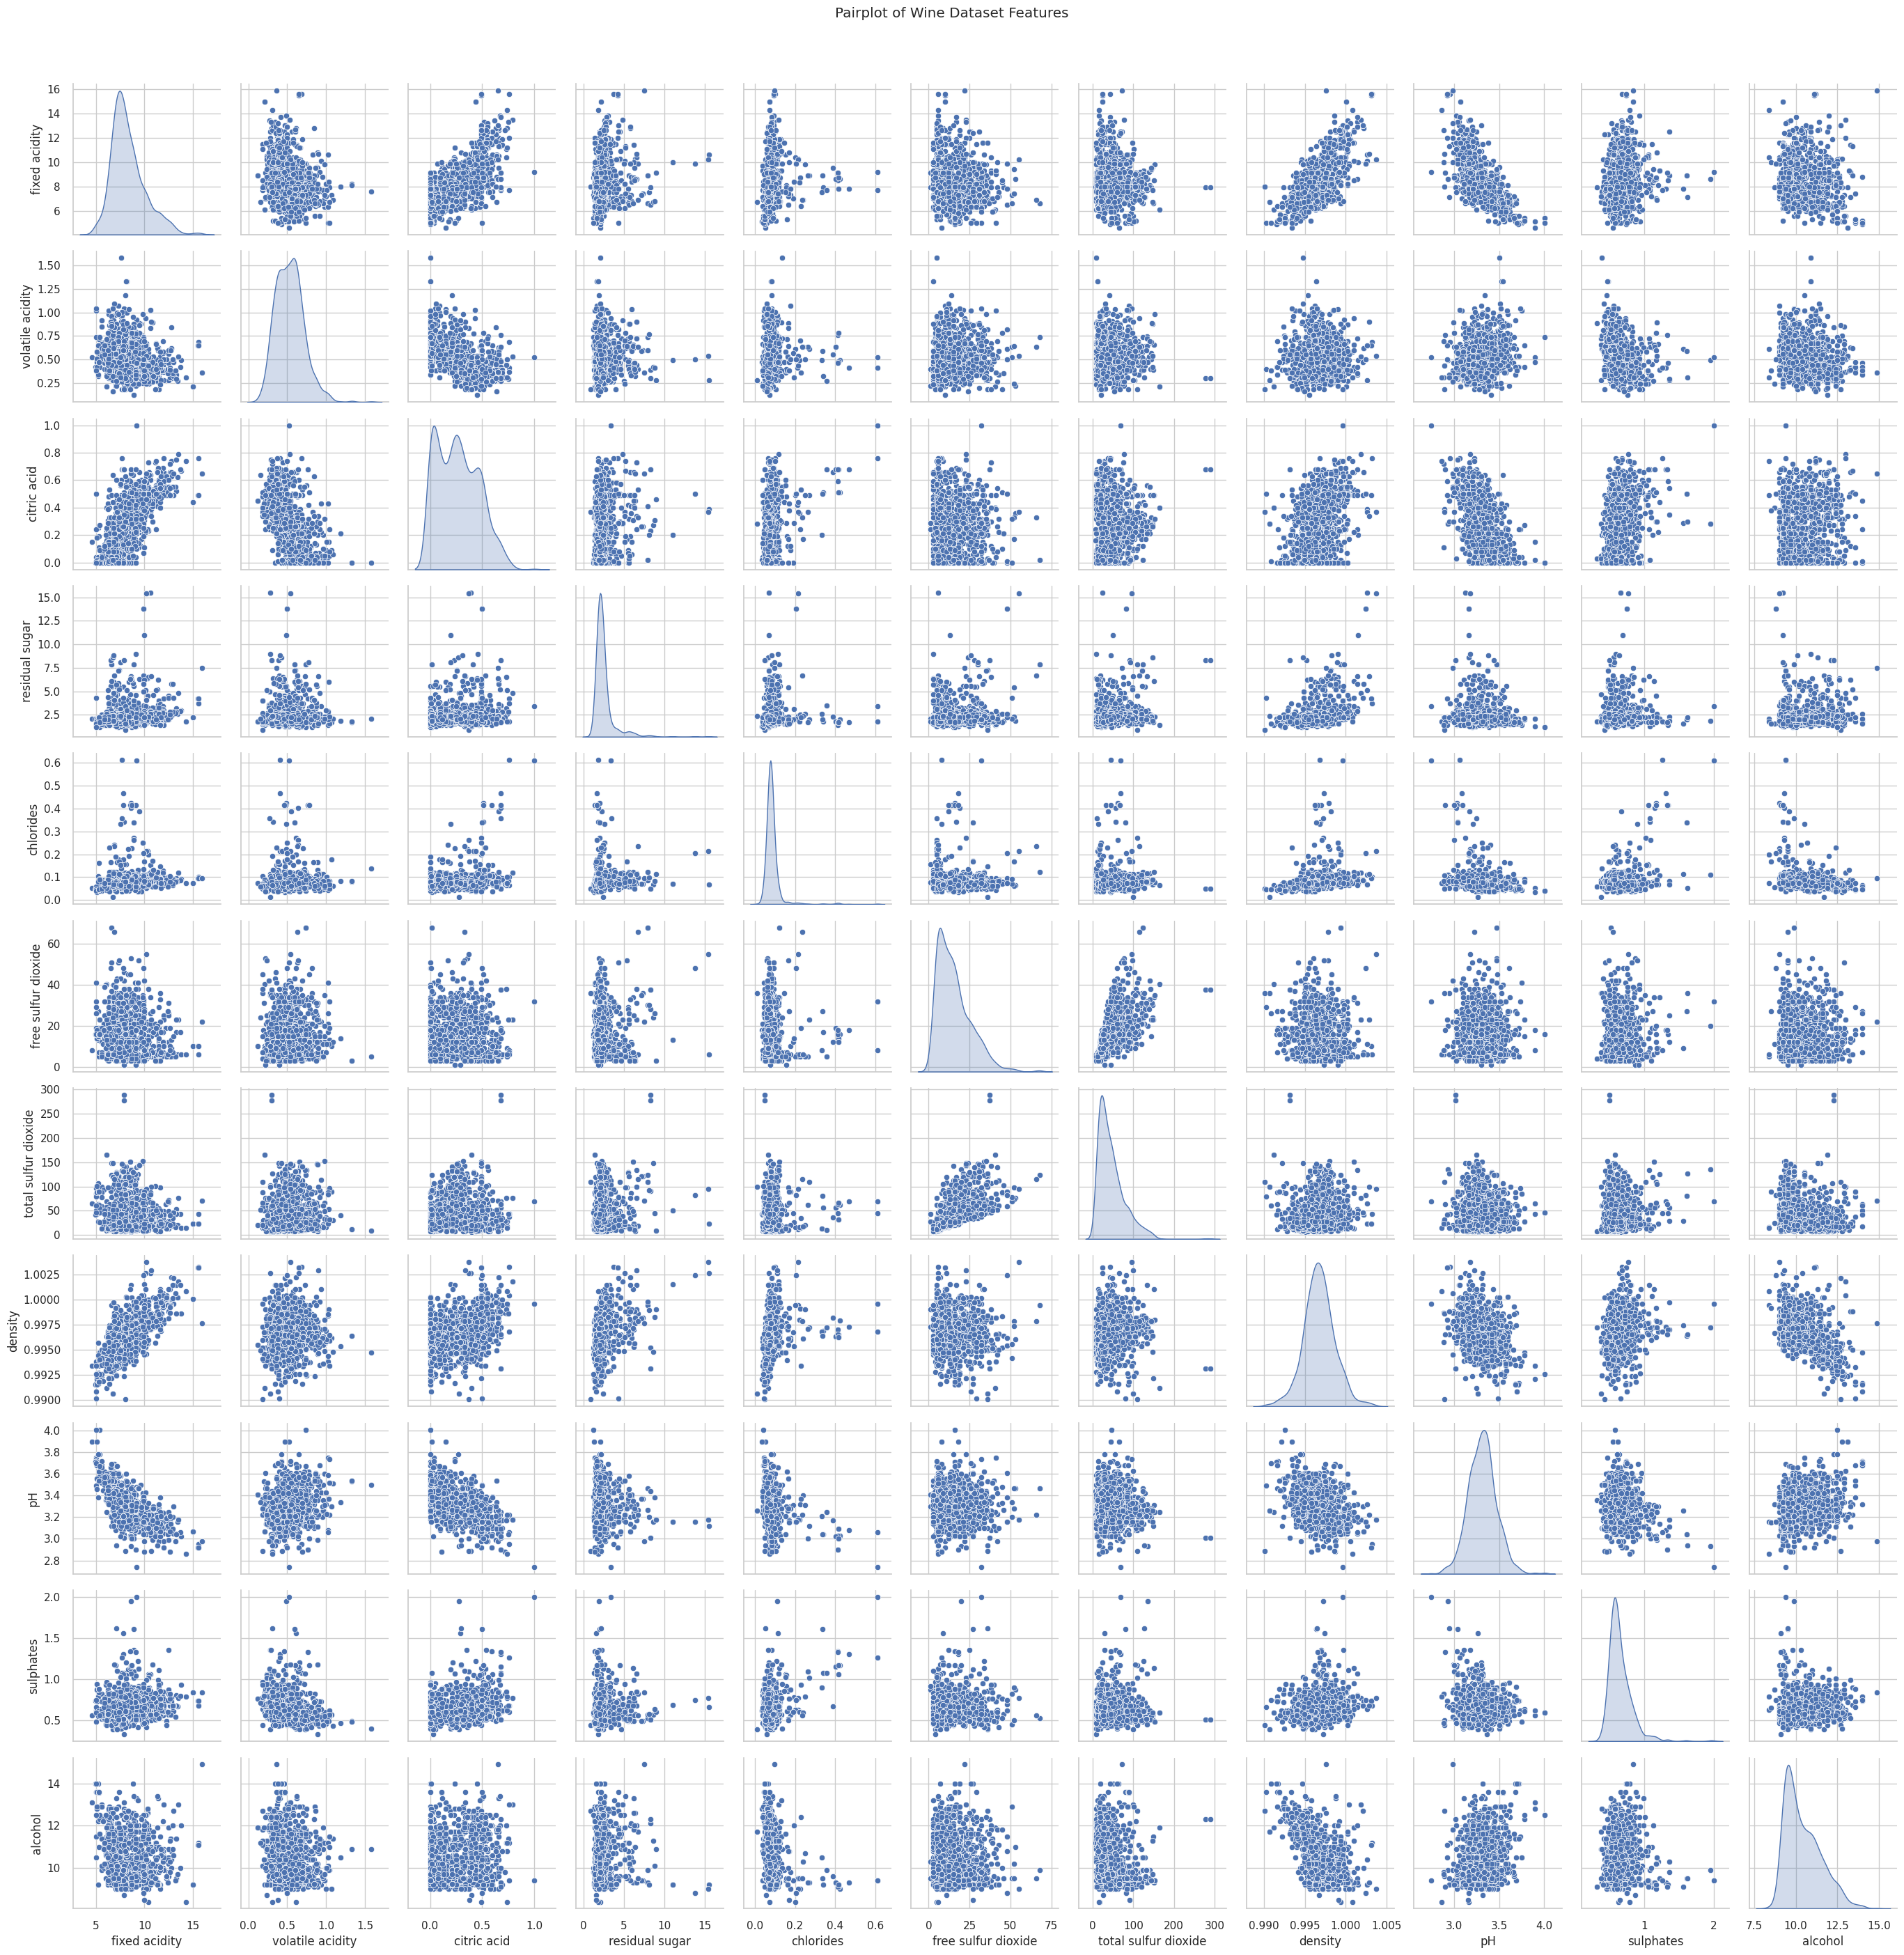

In [ ]:
sns.pairplot(df, diag_kind='kde')
plt.suptitle("Pairplot of Wine Dataset Features", y=1.02)
plt.tight_layout()
plt.show()

# **Boxplot of features**

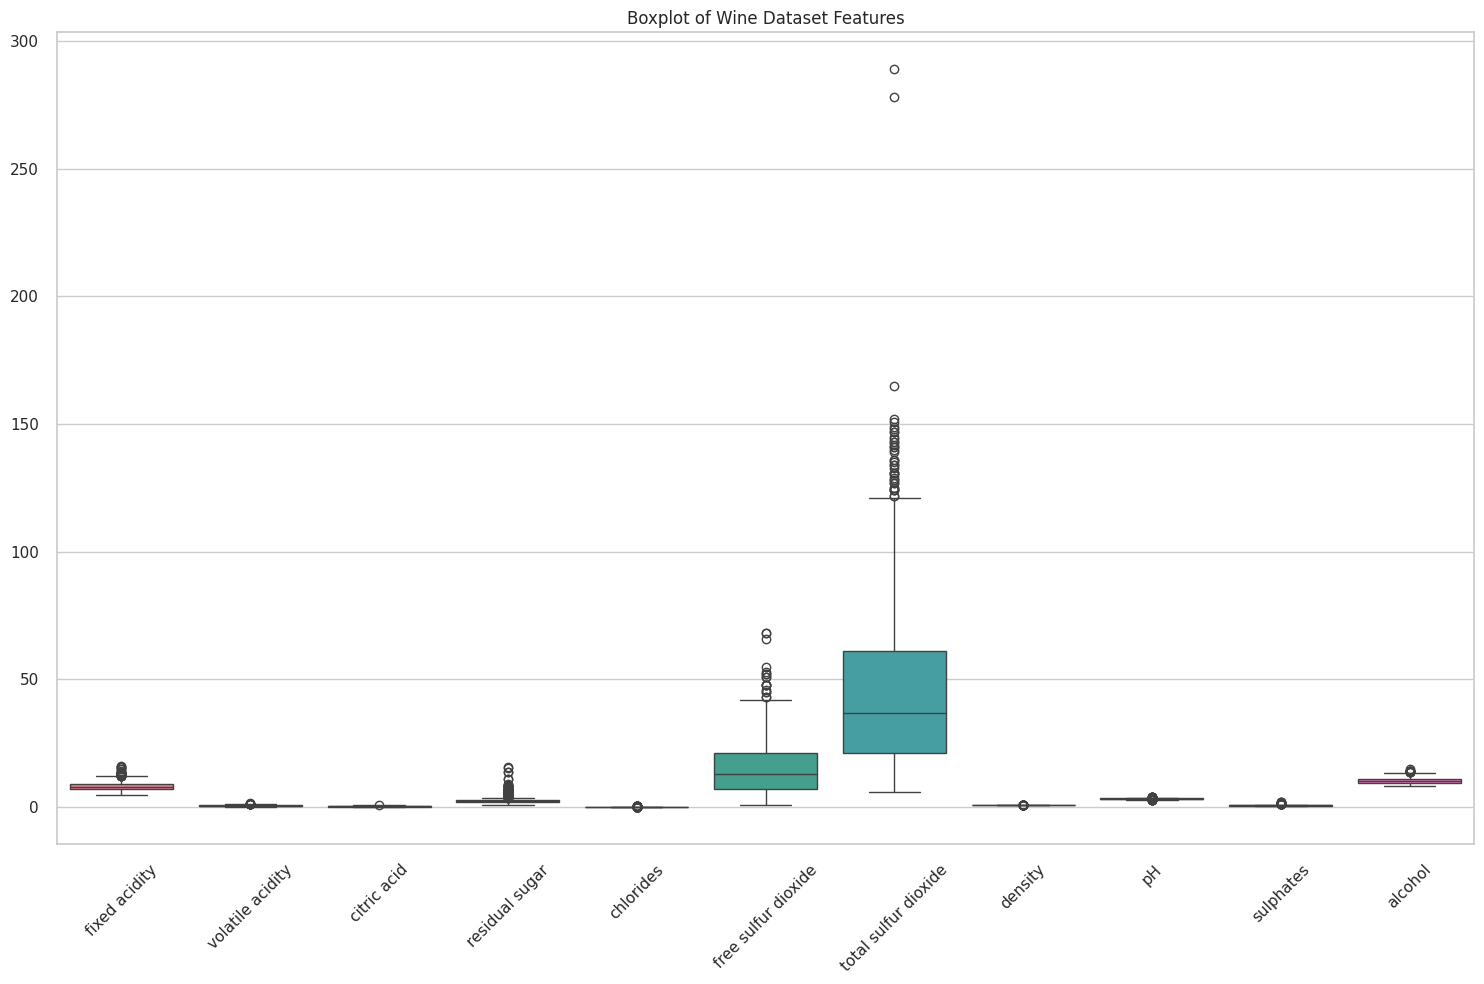

In [ ]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df)
plt.title("Boxplot of Wine Dataset Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Determine optimal number of clusters with the Elbow method

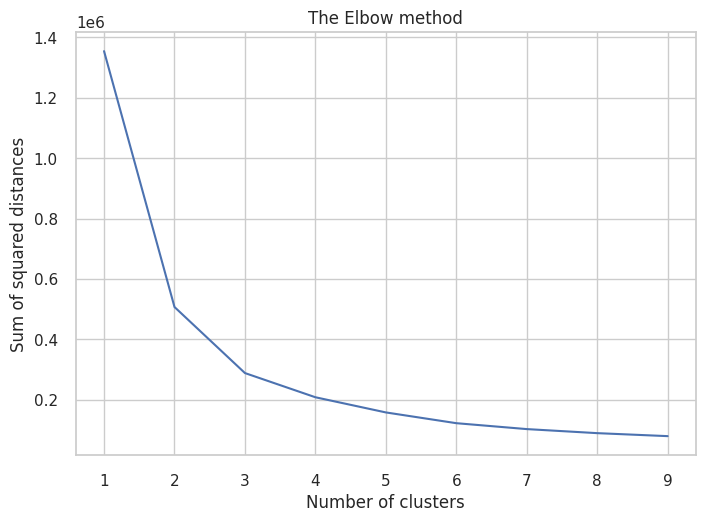

In [ ]:
wss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df)
    wss.append(kmeans.inertia_)
plt.plot(range(1, 10), wss)
plt.title('The Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squared distances')
plt.show()


# **Use KElbowVisualizer for visual selection of number of clusters**

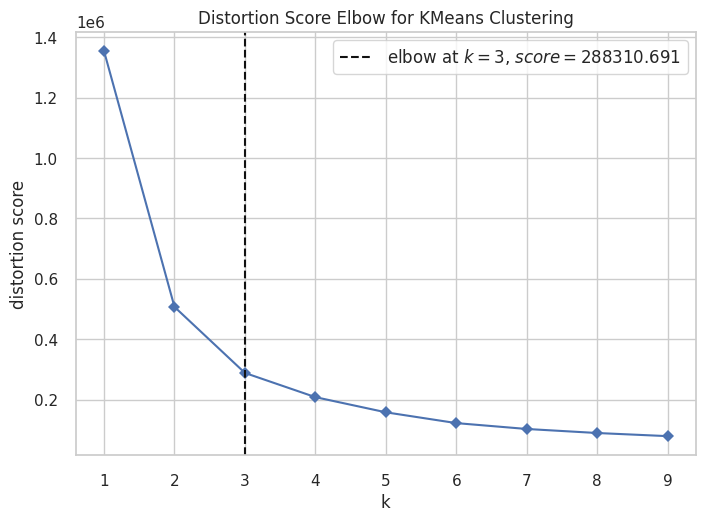

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1, 10), timings=False)
visualizer.fit(df)
visualizer.show()

# **Evaluate clustering with silhouette score**

For n_clusters = 2, the silhouette score is 0.60
For n_clusters = 3, the silhouette score is 0.53
For n_clusters = 4, the silhouette score is 0.50
For n_clusters = 5, the silhouette score is 0.48
For n_clusters = 6, the silhouette score is 0.45
For n_clusters = 7, the silhouette score is 0.40
For n_clusters = 8, the silhouette score is 0.40
For n_clusters = 9, the silhouette score is 0.39


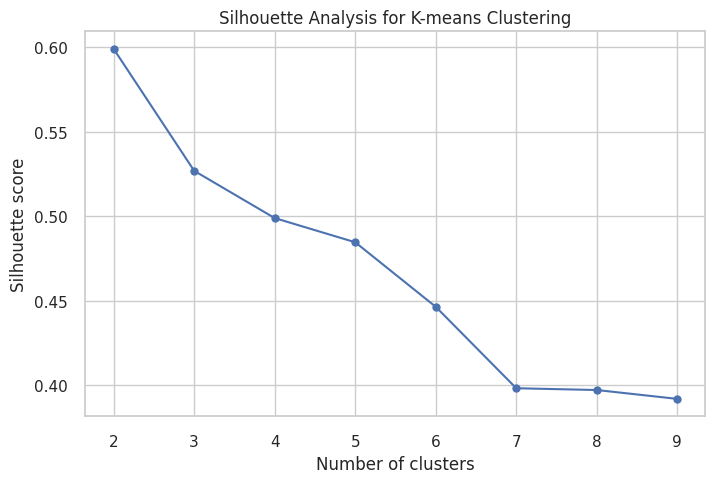

In [33]:
silhouette_scores = []
for n_clusters in range(2, 10):
    kmeans = KMeans(n_clusters=n_clusters, max_iter=100, random_state=42)
    kmeans.fit(df)
    score = silhouette_score(df, kmeans.labels_)
    silhouette_scores.append(score)
    print(f'For n_clusters = {n_clusters}, the silhouette score is {score:.2f}')

plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette Analysis for K-means Clustering')
plt.grid(True)
plt.show()

# **Standardize features for clustering**

In [34]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# **Perform K-means clustering**

In [35]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(scaled_features)

# **Visualize K-means clustering results**

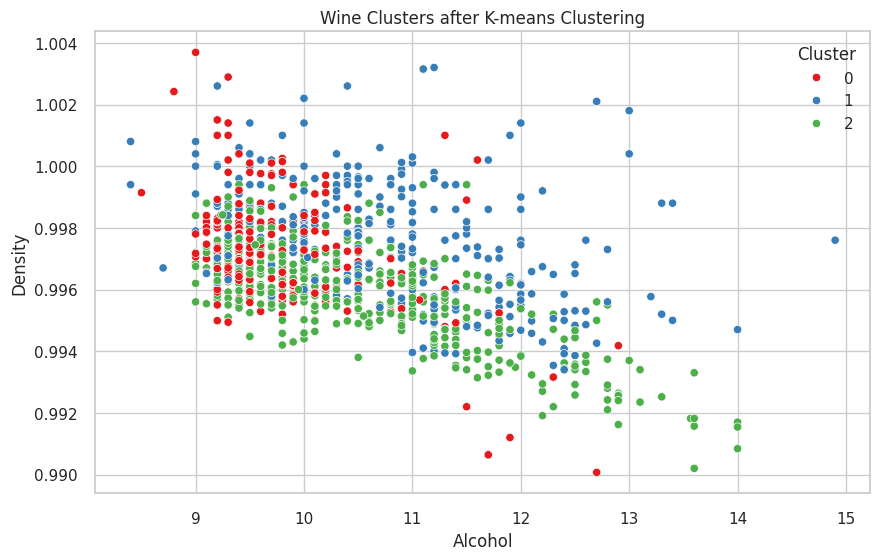

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='alcohol', y='density', hue='Cluster_KMeans', palette='Set1', legend='full')
plt.title("Wine Clusters after K-means Clustering")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


# **Perform hierarchical clustering**

In [37]:
clustering = AgglomerativeClustering(n_clusters=n_clusters).fit(scaled_features)
df['Cluster_Hierarchical'] = clustering.labels_

# **Visualize hierarchical clustering results**

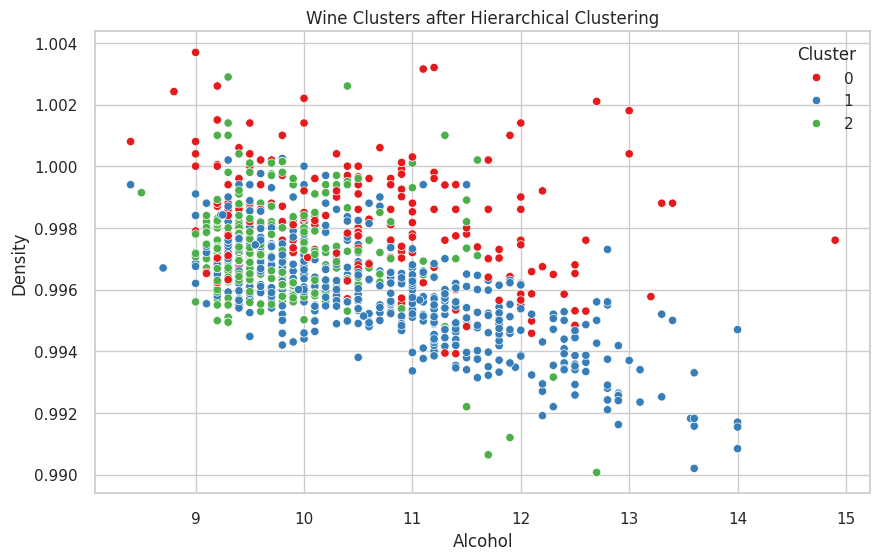

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='alcohol', y='density', hue='Cluster_Hierarchical', palette='Set1', legend='full')
plt.title("Wine Clusters after Hierarchical Clustering")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()